## 🔧 Step 1: Install Mantis

We begin by installing the `mantis` package directly from GitHub. This will download the latest version of the code and install all required dependencies.

In [1]:
# Clone the full Mantis repository and move into it
!git clone https://github.com/carsondudley1/Mantis.git
%cd Mantis

# Install the package in editable mode
!pip install -e .

fatal: destination path 'Mantis' already exists and is not an empty directory.
/content/Mantis
Obtaining file:///content/Mantis
  Preparing metadata (setup.py) ... done
  Attempting uninstall: mantis
    Found existing installation: mantis 1.0.0
    Uninstalling mantis-1.0.0:
      Successfully uninstalled mantis-1.0.0
  Running setup.py develop for mantis


## 📦 Step 2: Download the Pretrained Model

Mantis uses pretrained simulation-grounded foundation models for forecasting.  
In this tutorial, we’ll use the **4-week horizon model with covariates**.

This cell downloads the model file (~1 GB) from the [GitHub release](https://github.com/carsondudley1/Mantis/releases/tag/mantis-v1.0) and places it in a local `models/` directory.

In [2]:
# Download the 4-week model that takes covariates

!mkdir -p models
!wget -O models/mantis_4w_cov.pt https://github.com/carsondudley1/Mantis/releases/download/mantis-v1.0/mantis_4w_cov.pt

--2026-03-26 16:08:24--  https://github.com/carsondudley1/Mantis/releases/download/mantis-v1.0/mantis_4w_cov.pt
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/1028419690/2f95c870-6a12-4737-a6f9-a9332d52ae01?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-26T17%3A08%3A19Z&rscd=attachment%3B+filename%3Dmantis_4w_cov.pt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-26T16%3A07%3A34Z&ske=2026-03-26T17%3A08%3A19Z&sks=b&skv=2018-11-09&sig=PD6cmh%2B%2BlgK6rVMJ%2FunGBA4LbfQXk7kYyOkrlyxzf%2Fo%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NDU0NDkwNSwibmJmIjoxNzc0NTQxMzA1LCJwYXRoIjoicmVsZWFzZWFzc2V0c

## 📊 Step 3: Import Mantis and Load Example Data

We now import the `Mantis` model and load example COVID-19 hospitalization data.  
This dataset includes daily hospitalization counts for all 50 U.S. states, Washington DC, and Puerto Rico, with columns labeled by state abbreviation (e.g., `ca`, `ny`, `tx`).

We'll extract the weekly time series for each state and use that as our forecasting input.  

In [3]:
# ── Imports ─────────────────────────────────────────────────────────────────
from mantis import Mantis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm import tqdm

# ── Load data ────────────────────────────────────────────────────────────────
hosp_df   = pd.read_csv("data/covid_hospitalizations.csv")
deaths_df = pd.read_csv("data/covid_deaths.csv")

states = [c for c in deaths_df.columns]   # all state columns

## 🤖 Step 4: Initialize Mantis and Generate Forecasts

We now create an instance of the Mantis model — specifically, the 4-week horizon version with covariates.  
Then we pass in the hospitalization and death time series to generate forecasts.

Mantis returns 9 quantiles for each of the next 4 weeks, providing a full probabilistic forecast.


In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Model ────────────────────────────────────────────────────────────────────
model = Mantis(forecast_horizon=4, use_covariate=True)
BURN_IN    = 10
HORIZON    = 4

min_len        = min(len(deaths_df[s]) for s in states)
max_start_week = 32

week_indices = range(BURN_IN, max_start_week)

relative_mae_by_week      = {w: [] for w in week_indices}
lstm_relative_mae_by_week = {w: [] for w in week_indices}

# ── LSTM definition ──────────────────────────────────────────────────────────
class SmallLSTM(nn.Module):
    def __init__(self, lookback, horizon, hidden=32, n_features=2):
        super().__init__()
        self.lstm   = nn.LSTM(n_features, hidden, batch_first=True)
        self.linear = nn.Linear(hidden, horizon)

    def forward(self, x):                      # x: (batch, lookback, n_features)
        _, (h, _) = self.lstm(x)
        return self.linear(h.squeeze(0))       # (batch, horizon)

def fit_lstm_and_predict(target_series, covariate_series, lookback=4, epochs=200, lr=1e-3):
    if len(target_series) < lookback + HORIZON + 1:
        return None

    # Normalize each channel independently
    mu_t,  sigma_t  = target_series.mean(),    target_series.std()
    mu_c,  sigma_c  = covariate_series.mean(), covariate_series.std()
    if sigma_t == 0:
        return None
    sigma_c = sigma_c if sigma_c > 0 else 1.0

    norm_t = (target_series    - mu_t)  / sigma_t
    norm_c = (covariate_series - mu_c)  / sigma_c

    # Stack into (T, 2)
    combined = np.stack([norm_t, norm_c], axis=-1)

    # Build sequences
    X, y = [], []
    for i in range(len(combined) - lookback - HORIZON + 1):
        X.append(combined[i : i + lookback])           # (lookback, 2)
        y.append(norm_t[i + lookback : i + lookback + HORIZON])

    X = torch.tensor(np.array(X), dtype=torch.float32)   # (N, lookback, 2)
    y = torch.tensor(np.array(y), dtype=torch.float32)   # (N, horizon)

    if len(X) == 0:
        return None

    dataset = TensorDataset(X, y)
    loader  = DataLoader(dataset, batch_size=max(1, len(X)), shuffle=False)

    net       = SmallLSTM(lookback, HORIZON, n_features=2)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    criterion = nn.MSELoss()

    net.train()
    for _ in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            criterion(net(xb), yb).backward()
            optimizer.step()

    net.eval()
    with torch.no_grad():
        last_t = torch.tensor(norm_t[-lookback:], dtype=torch.float32)
        last_c = torch.tensor(norm_c[-lookback:], dtype=torch.float32)
        last   = torch.stack([last_t, last_c], dim=-1).unsqueeze(0)  # (1, lookback, 2)
        pred_norm = net(last).squeeze().numpy()

    return pred_norm * sigma_t + mu_t          # denormalize target only

# ── Main loop ────────────────────────────────────────────────────────────────
for state in tqdm(states, desc="States"):
    hosp_ts   = hosp_df[state].values
    deaths_ts = deaths_df[state].values

    for week in week_indices:
        true_future = deaths_ts[week : week + HORIZON]
        if np.any(np.isnan(true_future)):
            continue

        naive_pred = np.full(HORIZON, deaths_ts[week - 1])
        naive_mae  = np.mean(np.abs(naive_pred - true_future))
        if naive_mae == 0:
            continue

        # ── Mantis ───────────────────────────────────────────────────────────
        try:
            pred       = model.predict(
                time_series    = deaths_ts[:week],
                covariate      = hosp_ts[:week],
                target_type    = 2,
                covariate_type = 1,
            )
            median     = pred[:, 4]
            mantis_mae = np.mean(np.abs(median - true_future))
            relative_mae_by_week[week].append(mantis_mae / naive_mae)
        except Exception:
            pass

        # ── LSTM ─────────────────────────────────────────────────────────────
        try:
            lstm_pred = fit_lstm_and_predict(deaths_ts[:week], hosp_ts[:week])
            if lstm_pred is not None:
                lstm_mae = np.mean(np.abs(lstm_pred - true_future))
                lstm_relative_mae_by_week[week].append(lstm_mae / naive_mae)
        except Exception:
            pass

# ── Aggregate ────────────────────────────────────────────────────────────────
weeks        = sorted(week_indices)

mean_rel_mae = np.array([
    np.mean(relative_mae_by_week[w]) if relative_mae_by_week[w] else np.nan
    for w in weeks
])
lstm_mean_rel_mae = np.array([
    np.mean(lstm_relative_mae_by_week[w]) if lstm_relative_mae_by_week[w] else np.nan
    for w in weeks
])

window  = 5
rolling_mantis = np.convolve(mean_rel_mae,      np.ones(window) / window, mode="valid")
rolling_lstm   = np.convolve(lstm_mean_rel_mae, np.ones(window) / window, mode="valid")
roll_x         = list(weeks)[window - 1:]

States: 100%|██████████| 52/52 [14:06<00:00, 16.28s/it]


## 📈 Step 5: Plot Forecast Error vs How Long into the Outbreak we are

We now visualize all of the forecasts errors on a **single plot**.


This provides a realistic view of how Mantis forecast accuracy evolves over time (although this is just one example).

Saved → mantis_vs_lstm_relative_mae.pdf


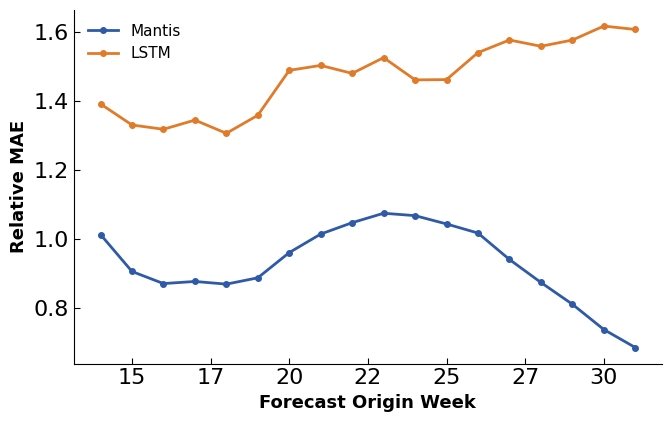

Weeks evaluated     : 22
States included     : 52
Mantis mean rel MAE : 0.920
LSTM   mean rel MAE : 1.485
Mantis beats naive  : 68% of weeks
LSTM   beats naive  : 0% of weeks


In [6]:
# ── Plot ─────────────────────────────────────────────────────────────────────
import matplotlib as mpl

mpl.rcParams.update({
    "font.family":      "sans-serif",
    "font.size":        16,
    "axes.labelsize":   13,
    "axes.labelweight": "bold",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "xtick.direction":  "in",
    "ytick.direction":  "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
})

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(roll_x, rolling_mantis, color="#2f5aa8", linewidth=2.0,
        marker="o", markersize=4, label="Mantis")
ax.plot(roll_x, rolling_lstm,   color="#e07b2a", linewidth=2.0,
        marker="o", markersize=4, label="LSTM")

ax.set_xlabel("Forecast Origin Week")
ax.set_ylabel("Relative MAE")
ax.legend(frameon=False, fontsize=11)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))

fig.tight_layout()

out_path = "mantis_vs_lstm_relative_mae.pdf"
fig.savefig(out_path, format="pdf", bbox_inches="tight", dpi=300)
print(f"Saved → {out_path}")
plt.show()

# ── Summary stats ────────────────────────────────────────────────────────────
print(f"Weeks evaluated     : {len(weeks)}")
print(f"States included     : {len(states)}")
print(f"Mantis mean rel MAE : {np.nanmean(mean_rel_mae):.3f}")
print(f"LSTM   mean rel MAE : {np.nanmean(lstm_mean_rel_mae):.3f}")
print(f"Mantis beats naive  : {np.mean(mean_rel_mae[~np.isnan(mean_rel_mae)] < 1.0):.0%} of weeks")
print(f"LSTM   beats naive  : {np.mean(lstm_mean_rel_mae[~np.isnan(lstm_mean_rel_mae)] < 1.0):.0%} of weeks")